# 선형모델


---
---



In [ ]:
# 0) 환경 점검: 설치된 폰트 실제 파일이 있는지 먼저 확인
!ls -R /usr/share/fonts | head -n 50

# 1) (이미 설치했다면 생략 가능) 한글 폰트 설치
!apt-get -y update
!apt-get -y install fonts-nanum fonts-noto-cjk

# 2) 시스템 폰트 캐시 재생성
!fc-cache -fv

# 3) Matplotlib 내부 폰트 캐시 삭제 (중요)
import os, shutil
import matplotlib
cache_dir = matplotlib.get_cachedir()      # 보통 ~/.cache/matplotlib
# print("matplotlib cache:", cache_dir)
shutil.rmtree(cache_dir, ignore_errors=True)

# 4) 런타임 재시작 필요 없이, 폰트 매니저 강제 리로드
from matplotlib import font_manager
_ = font_manager._load_fontmanager(try_read_cache=False)

# 5) 폰트 존재 여부 확인 (fc-list와 파이썬에서 모두 확인)
# !fc-list | grep -i "nanum\|noto" | head -n 40

# from matplotlib import font_manager
# fonts = font_manager.findSystemFonts()
# [f for f in fonts if ("Nanum" in f or "NotoSansCJK" in f or "Noto" in f)][:10]


# 6) 한글 폰트 지정
import seaborn as sns
import numpy as np
from matplotlib import font_manager, pyplot as plt

font_path = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
font_manager.fontManager.addfont(font_path)
family_name = font_manager.FontProperties(fname=font_path).get_name()
# print("적용할 패밀리명:", family_name)

plt.rcParams["font.family"] = family_name
plt.rcParams["axes.unicode_minus"] = False
print("✅ 나눔폰트 설정 완료")# 폰트 지정

/usr/share/fonts:
truetype

/usr/share/fonts/truetype:
humor-sans
liberation

/usr/share/fonts/truetype/humor-sans:
Humor-Sans.ttf

/usr/share/fonts/truetype/liberation:
LiberationMono-BoldItalic.ttf
LiberationMono-Bold.ttf
LiberationMono-Italic.ttf
LiberationMono-Regular.ttf
LiberationSans-BoldItalic.ttf
LiberationSans-Bold.ttf
LiberationSans-Italic.ttf
LiberationSansNarrow-BoldItalic.ttf
LiberationSansNarrow-Bold.ttf
LiberationSansNarrow-Italic.ttf
LiberationSansNarrow-Regular.ttf
LiberationSans-Regular.ttf
LiberationSerif-BoldItalic.ttf
LiberationSerif-Bold.ttf
LiberationSerif-Italic.ttf
LiberationSerif-Regular.ttf
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 https://cli.github.com/packages stable InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:6 http://security.ubuntu.com/

✅ 나눔폰트 설정 완료


## **1. 선형모델 이해**
- **선형모델**은 머신러닝의 기초이자 많은 복잡한 모델의 출발점 해석 가능성이 중요한 상황에서 특히 유용함
- 선형 모델은 입력 특징(feature)의 선형 결합( 𝑤^⊤ 𝑥+𝑏)으로 예측하고  
- 분류는 이를 로지스틱/소프트맥스로 확률화하며,  
- 정규화(L1/L2) 로 과적합을 억제하는  
- 빠르고 해석 가능한 볼록 최적화 기반의 **기본선(Baseline)모델**

### 예제 : 간단 선형모델

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.datasets import make_regression, make_classification

# 회귀 데이터
X_reg, y_reg = make_regression(n_samples=100, n_features=5, random_state=42)

# 분류 데이터
X_clf, y_clf = make_classification(n_samples=100, n_features=5, random_state=42)

# 회귀 모델들
# model = LinearRegression()
# linear_reg =model.fit(X_reg, y_reg)
linear_reg = LinearRegression().fit(X_reg, y_reg)
ridge_reg = Ridge(alpha=1.0).fit(X_reg, y_reg)
lasso_reg = Lasso(alpha=1.0).fit(X_reg, y_reg)

# 분류 모델
logistic_clf = LogisticRegression().fit(X_clf, y_clf)

print("선형회귀 R²:", linear_reg.score(X_reg, y_reg))
print("릿지회귀(L2) R²:", ridge_reg.score(X_reg, y_reg))
print("라쏘회귀(L1) R²:", lasso_reg.score(X_reg, y_reg))
print("로지스틱회귀 정확도:", logistic_clf.score(X_clf, y_clf))

선형회귀 R²: 1.0
릿지회귀(L2) R²: 0.9998671033631022
라쏘회귀(L1) R²: 0.9997093894951757
로지스틱회귀 정확도: 1.0


### 예제 : Tensorflow를 이용한 다층 신경망 회귀 모델

In [ ]:
import tensorflow as tf
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# 복잡한 데이터 생성
X, y = make_regression(n_samples=1000,
                       n_features=10,
                       noise=0.1,
                       random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== 다층 신경망 회귀 모델 ===")

# 다층 모델 구성
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(10,)),  # 은닉층 1
    tf.keras.layers.Dense(32, activation='relu'),                     # 은닉층 2
    tf.keras.layers.Dense(1)                                          # 출력층
])

# 컴파일 및 훈련
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=1)

# 평가
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"테스트 MSE: {test_loss:.2f}")
print(f"테스트 MAE: {test_mae:.2f}")

=== 다층 신경망 회귀 모델 ===
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 17660.5488 - mae: 105.0558 - val_loss: 14818.6143 - val_mae: 94.2770
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 18789.8242 - mae: 109.8719 - val_loss: 14693.2061 - val_mae: 93.8524
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 19045.2285 - mae: 109.7436 - val_loss: 14490.6191 - val_mae: 93.1488
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17397.8320 - mae: 105.5389 - val_loss: 14165.5801 - val_mae: 92.0052
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17604.6074 - mae: 105.4246 - val_loss: 13595.2061 - val_mae: 89.9396
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16405.3730 - mae: 102.4688 - val_loss: 12760.5293 - val_mae: 86.8520
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 14207.9609 - mae: 95.3548 - val_loss: 11608.1748 - val_mae: 82.4012
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 15369.1748 - mae: 97.3838 - val_loss: 10131.4863 - val_ma



---



## **선형 회귀**

- 데이터의 추세를 그래프로 표현하여 이후의 패턴을 예측하는 데 활용하는 통계 분석 방법론 --> **회귀 분석**
- label(Y)과 feature(X)의 관계를 잘 설명하는 모델을 만드는 것 --> **머신러닝**
- 최적의 직선을 기반으로 예측하는 알고리즘 --> **선형 회귀(Linear Regression)**

- $𝑦(𝑤, 𝑥)=𝑤_0+ 𝑤_1 𝑥_1  +...+ 𝑤_𝑝 𝑥_𝑝$   
    - $ 𝒙 = 독립변수,   w = 가중치,   y = 종속변수$

### **예제 : 기본 선형 회귀**

### **예제 : Tensorflow(딥러닝)를 이용한 선형회귀**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# 1. 데이터 생성
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 모델 생성 및 훈련
model = LinearRegression()
model.fit(X_train, y_train)

# 3. 예측
y_pred = model.predict(X_test)

# 4. 성능 평가
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score: {r2:.3f}")
print(f"MSE: {mse:.3f}")
print(f"모델 계수: {model.coef_[0]:.3f}")
print(f"절편: {model.intercept_:.3f}")

TensorFlow 버전: 2.19.0
=== 데이터 생성 ===
훈련 데이터 크기: (800, 1)
테스트 데이터 크기: (200, 1)

=== 모델 구성 ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)


=== 모델 훈련 ===
Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 401.0332 - mae: 15.9693 - val_loss: 452.6766 - val_mae: 17.0418
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 404.9608 - mae: 16.1441 - val_loss: 451.8698 - val_mae: 17.0261
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 387.1461 - mae: 15.8562 - val_loss: 451.0361 - val_mae: 17.0100
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 447.4899 - mae: 16.7487 - val_loss: 450.2160 - val_mae: 16.9941
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 412.4270 - mae: 15.8546 - val_loss: 449.4051 - val_mae: 16.9786
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 383.2312 - mae: 15.4739 - val_loss: 448.5928 - val_mae: 16.9628
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 394.4768 - mae: 16.0051 - val_loss: 447.7762 - val_mae: 16.9467
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 406.0621 - mae: 15.9888 - val_loss: 446.9379 - val_mae: 16.9304


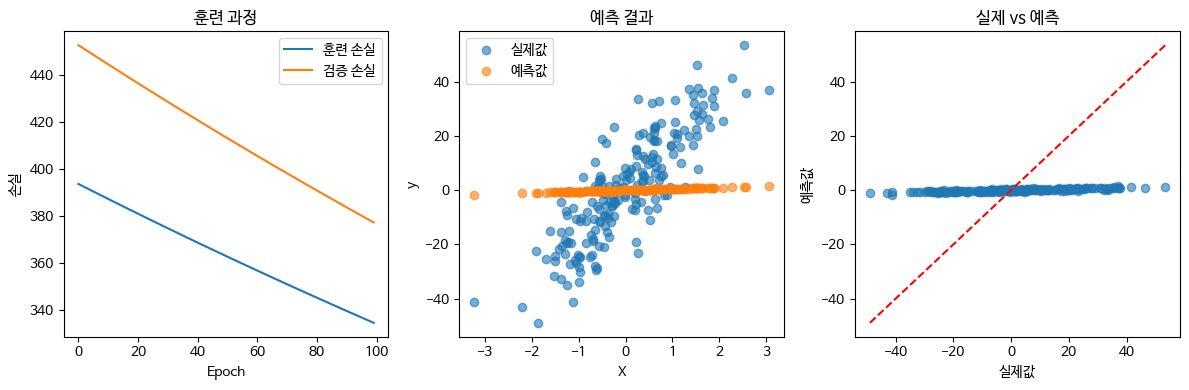

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams["font.family"] = "NanumBarunGothic"

print("TensorFlow 버전:", tf.__version__)

# 1. 데이터 준비
print("=== 데이터 생성 ===")
X, y = make_regression(n_samples=1000, n_features=1, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 정규화 (선택사항이지만 권장)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"훈련 데이터 크기: {X_train.shape}")
print(f"테스트 데이터 크기: {X_test.shape}")

# 2. 모델 구성
print("\n=== 모델 구성 ===")
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(1,))  # 입력 1개, 출력 1개
])

# 3. 모델 컴파일
model.compile(
    optimizer='adam',           # 최적화 알고리즘
    loss='mean_squared_error',  # 손실 함수
    metrics=['mae']             # 평가 지표
)

# 모델 구조 확인
model.summary()

# 4. 모델 훈련
print("\n=== 모델 훈련 ===")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,              # 훈련 반복 횟수
    batch_size=32,           # 배치 크기
    validation_split=0.2,    # 검증 데이터 비율
    verbose=1                # 훈련 과정 출력
)

# 5. 모델 평가
print("\n=== 모델 평가 ===")
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"테스트 손실 (MSE): {test_loss:.2f}")
print(f"테스트 MAE: {test_mae:.2f}")

# 6. 예측
y_pred = model.predict(X_test_scaled)

# R² Score 계산
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.3f}")

# 7. 결과 시각화
plt.figure(figsize=(12, 4))

# 훈련 과정
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='훈련 손실')
plt.plot(history.history['val_loss'], label='검증 손실')
plt.title('훈련 과정')
plt.xlabel('Epoch')
plt.ylabel('손실')
plt.legend()

# 예측 결과
plt.subplot(1, 3, 2)
plt.scatter(X_test, y_test, alpha=0.6, label='실제값')
plt.scatter(X_test, y_pred, alpha=0.6, label='예측값')
plt.title('예측 결과')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

# 실제 vs 예측
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('실제 vs 예측')
plt.xlabel('실제값')
plt.ylabel('예측값')

plt.tight_layout()
plt.show()

### **[실습] 선형회귀 실습하기**

#### **1) 데이터 구성하기**

In [ ]:
# 라이브러리 불러오기 (numpy, matplotlib)
import numpy as np
import matplotlib.pyplot as plt

# 렌덤 시드 고정
np.random.seed(2024)

In [ ]:
# x는 1~10, y = 4*x+7인 학습 데이터 생성하기
x = []
y = []
for i in range(1,11):
    x.append(i)
    y.append(4*i+7)

In [ ]:
x = list(range(1,11))
y = [4*i+7 for i in x]

In [ ]:
# 데이터 확인하기
print('x : ', x)
print('y : ', y)

x :  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y :  [11, 15, 19, 23, 27, 31, 35, 39, 43, 47]


#### **2) 선형회귀 학습 하기**

In [ ]:
# 선형회귀 라이브러리 불러오기
from sklearn.linear_model import LinearRegression
# 선형회귀 생성하기
reg = LinearRegression()

In [ ]:
# 학습을 위해 1행10열 구성 데이터를 10행 1열로 변경하기
# 사이킷런은 ndarray 타입을 input으로 받는다.
x = np.array(x).reshape(-1, 1)

# 데이터 확인하기
print("학습 데이터 확인")
print('x :' ,x)
print('x.shape : ', x.shape)

학습 데이터 확인
x : [[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
x.shape :  (10, 1)


In [ ]:
# 학습하기
reg.fit(x,y)

LinearRegression()

In [ ]:
reg.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [ ]:
# 산식 추정을 위한 기울기(coef) 및 절편(intercept) 확인하기
print(f'''기울기 및 절편 확인 coef = {reg.coef_}, intercept = {reg.intercept_} ''')

기울기 및 절편 확인 coef = [4.], intercept = 6.9999999999999964 


In [ ]:
# 절편과 기울기로 결과를 수동 계산하여 비교값 생성하기
coef_intercept = x * reg.coef_[0] + reg.intercept_
print("계산 결과")
print(coef_intercept)

계산 결과
[[11.]
 [15.]
 [19.]
 [23.]
 [27.]
 [31.]
 [35.]
 [39.]
 [43.]
 [47.]]


#### **3) 결과 비교를 위해 그래프 그리기**

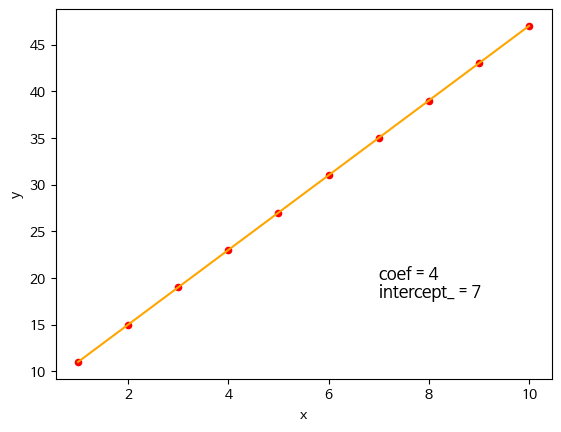

In [ ]:
# scatter plot 그래프그리기
plt.scatter(x, y, color = 'r', s = 20)
# 선 그래프 그리기
plt.plot(x, coef_intercept, color = 'orange')
# coef 값 그래프 내에 텍스트 삽입하기
plt.text(7, 20, 'coef = %.0f'%reg.coef_[0], size = 12)
# intercept 값 그래프 내에 텍스트 삽입하기
plt.text(7, 18, 'intercept_ = %.0f'%reg.intercept_, size = 12)
# x축(가로) label 설정하기
plt.xlabel('x')
# y축(세로) label 설정하기
plt.ylabel('y')
plt.show()

### **[실습] 사례기반 선형회귀 모델링**

#### **1) 데이터 전처리하기**

In [ ]:
# 판다스 라이브러리 불러오기
import pandas as pd

In [ ]:
# 데이터 불러오기
df = pd.read_csv("국민건강보험공단_건강검진정보_20211229.CSV", encoding='cp949')

In [ ]:
# pandas display 옵션 조정을 통해 View 범위 확장하기
pd.set_option('display.max_columns', None) # display 옵션을 통한 전체 열 확장

In [ ]:
# 데이터 확인하기 (상위 5개)
df.head()

,기준년도,가입자 일련번호,시도코드,성별코드,연령대 코드(5세단위),신장(5Cm단위),체중(5Kg 단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기 혈압,이완기 혈압,식전혈당(공복혈당),총 콜레스테롤,트리글리세라이드,HDL 콜레스테롤,LDL 콜레스테롤,혈색소,요단백,혈청크레아티닌,(혈청지오티)AST,(혈청지오티)ALT,감마 지티피,흡연상태,음주여부,구강검진 수검여부,치아우식증유무,치석,데이터 공개일자
0,2020,1,36,1,9,165,60,72.1,1.2,1.5,1.0,1.0,127.0,79.0,90.0,188.0,58.0,58.0,118.0,15.0,1.0,1.1,21.0,27.0,21.0,1.0,0.0,0,NaN,NaN,2021-12-29
1,2020,2,27,2,13,150,65,81.0,0.8,0.8,1.0,1.0,110.0,73.0,87.0,NaN,NaN,NaN,NaN,12.7,1.0,0.5,18.0,15.0,15.0,1.0,0.0,0,NaN,NaN,2021-12-29
2,2020,3,11,2,12,155,55,70.0,0.6,0.7,1.0,1.0,123.0,80.0,102.0,NaN,NaN,NaN,NaN,12.8,1.0,0.7,27.0,25.0,7.0,1.0,0.0,0,NaN,NaN,2021-12-29
3,2020,4,31,1,13,160,70,90.8,1.0,1.0,1.0,2.0,134.0,84.0,146.0,NaN,NaN,NaN,NaN,16.4,1.0,1.2,65.0,97.0,72.0,1.0,0.0,1,0.0,0.0,2021-12-29
4,2020,5,41,2,12,155,50,75.2,1.5,1.2,1.0,1.0,144.0,89.0,110.0,220.0,171.0,53.0,133.0,12.4,1.0,0.7,18.0,17.0,14.0,1.0,0.0,0,NaN,NaN,2021-12-29


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 31 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   기준년도          1000000 non-null  int64  
 1   가입자 일련번호      1000000 non-null  int64  
 2   시도코드          1000000 non-null  int64  
 3   성별코드          1000000 non-null  int64  
 4   연령대 코드(5세단위)  1000000 non-null  int64  
 5   신장(5Cm단위)     1000000 non-null  int64  
 6   체중(5Kg 단위)    1000000 non-null  int64  
 7   허리둘레          999892 non-null   float64
 8   시력(좌)         999743 non-null   float64
 9   시력(우)         999748 non-null   float64
 10  청력(좌)         999778 non-null   float64
 11  청력(우)         999770 non-null   float64
 12  수축기 혈압        992468 non-null   float64
 13  이완기 혈압        992466 non-null   float64
 14  식전혈당(공복혈당)    992398 non-null   float64
 15  총 콜레스테롤       402306 non-null   float64
 16  트리글리세라이드      402322 non-null   float64
 17  HDL 콜레스테롤     402315 non-nul

In [ ]:
df.describe()

,기준년도,가입자 일련번호,시도코드,성별코드,연령대 코드(5세단위),신장(5Cm단위),체중(5Kg 단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기 혈압,이완기 혈압,식전혈당(공복혈당),총 콜레스테롤,트리글리세라이드,HDL 콜레스테롤,LDL 콜레스테롤,혈색소,요단백,혈청크레아티닌,(혈청지오티)AST,(혈청지오티)ALT,감마 지티피,흡연상태,음주여부,구강검진 수검여부,치아우식증유무,치석
count,1000000.0,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,999892.000000,999743.000000,999748.000000,999778.000000,999770.000000,992468.000000,992466.000000,992398.000000,402306.000000,402322.000000,402315.000000,394471.000000,992389.00000,987859.000000,992398.000000,992399.000000,992398.000000,992397.000000,999657.000000,999804.000000,1000000.000000,331383.00000,331382.000000
mean,2020.0,500000.500000,34.047725,1.489311,11.917757,160.964085,63.060790,82.357094,0.933045,0.935036,1.046334,1.044071,124.831874,76.815972,104.257728,198.457729,133.837283,56.769684,115.823673,14.20946,1.122333,0.851984,27.698337,26.759641,37.778292,1.557421,0.584800,0.331384,0.16859,0.584661
std,0.0,288675.278933,12.443883,0.499886,2.171036,9.197899,12.269907,9.622632,0.637453,0.644911,0.218147,0.212804,14.751504,9.990877,25.412529,43.210579,99.979640,16.530316,39.185302,1.55418,0.493386,0.369630,25.286659,25.835091,51.815871,0.783742,0.492757,0.470711,0.37439,0.589833
min,2020.0,1.000000,11.000000,1.000000,9.000000,130.000000,30.000000,5.800000,0.100000,0.100000,1.000000,1.000000,64.000000,30.000000,1.000000,54.000000,2.000000,1.000000,1.000000,1.00000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000
25%,2020.0,250000.750000,27.000000,1.000000,10.000000,155.000000,55.000000,76.000000,0.700000,0.700000,1.000000,1.000000,115.000000,70.000000,91.000000,170.000000,77.000000,46.000000,89.000000,13.20000,1.000000,0.700000,20.000000,16.000000,16.000000,1.000000,0.000000,0.000000,0.00000,0.000000
50%,2020.0,500000.500000,41.000000,1.000000,12.000000,160.000000,60.000000,82.000000,0.900000,0.900000,1.000000,1.000000,124.000000,77.000000,99.000000,197.000000,110.000000,55.000000,115.000000,14.20000,1.000000,0.800000,24.000000,21.000000,24.000000,1.000000,1.000000,0.000000,0.00000,1.000000
75%,2020.0,750000.250000,44.000000,2.000000,13.000000,170.000000,70.000000,89.000000,1.200000,1.200000,1.000000,1.000000,134.000000,83.000000,109.000000,225.000000,160.000000,65.000000,140.000000,15.30000,1.000000,1.000000,30.000000,31.000000,40.000000,2.000000,1.000000,1.000000,0.00000,1.000000
max,2020.0,1000000.000000,49.000000,2.000000,18.000000,195.000000,135.000000,999.000000,9.900000,9.900000,3.000000,3.000000,260.000000,190.000000,950.000000,2416.000000,6999.000000,960.000000,2395.000000,25.00000,6.000000,95.000000,8712.000000,5990.000000,2630.000000,3.000000,1.000000,1.000000,1.00000,2.000000


In [ ]:
# 가설을 참고하여 데이터 일부 삭제하기
# 시력, 청력, 치아 관련 칼럼은 관계없다는 가정으로 열 제거하기
df.drop(["치아우식증유무", '치석','시력(좌)', '시력(우)', '청력(좌)',  '청력(우)', '구강검진 수검여부'], axis=1, inplace=True)

In [ ]:
# 기준년도 칼럼 확인하기 (모두 '2020' 동일 값이므로 '기준년도' 칼럼 삭제)
print("기준년도 칼럼 확인")
df.기준년도.value_counts()

기준년도 칼럼 확인


,count
기준년도,
2020,1000000


In [ ]:
# 가입자 일련번호 칼럼 확인하기 (모두 unique한 값으로 확인되어 '가입자 일련번호' 컬럼 삭제)
print("가입자 일련번호 칼럼 확인")
df["가입자 일련번호"].value_counts()

가입자 일련번호 칼럼 확인


,count
가입자 일련번호,
999984,1
999983,1
999982,1
999981,1
999980,1
...,...
5,1
4,1
3,1


In [ ]:
# 성별코드 칼럼 확인하기
print("성별코드 칼럼 확인")
df.성별코드.value_counts()

성별코드 칼럼 확인


,count
성별코드,
1,510689
2,489311


In [ ]:
# 불필요한 데이터 삭제하기
df.drop(["기준년도", '가입자 일련번호', '데이터 공개일자', '성별코드', '시도코드'], axis=1, inplace=True)

In [ ]:
# 별도의 test 데이터 추출하기
test = df[df['LDL 콜레스테롤'].isnull()]

In [ ]:
# NaN 데이터 행 단위로 삭제하기
train = df.dropna(axis=0)

In [ ]:
# 학습 데이터 확인하기
print("학습 데이터 확인")
train.head(1)

학습 데이터 확인


,연령대 코드(5세단위),신장(5Cm단위),체중(5Kg 단위),허리둘레,수축기 혈압,이완기 혈압,식전혈당(공복혈당),총 콜레스테롤,트리글리세라이드,HDL 콜레스테롤,LDL 콜레스테롤,혈색소,요단백,혈청크레아티닌,(혈청지오티)AST,(혈청지오티)ALT,감마 지티피,흡연상태,음주여부
0,9,165,60,72.1,127.0,79.0,90.0,188.0,58.0,58.0,118.0,15.0,1.0,1.1,21.0,27.0,21.0,1.0,0.0


In [ ]:
# 정답 데이터 생성하기
y = train['LDL 콜레스테롤']

In [ ]:
# 학습 데이터 생성하기
x = train.drop('LDL 콜레스테롤', axis=1)

In [ ]:
# validation set 추출을 위한 train_test_split 라이브러리 불러오기
from sklearn.model_selection import train_test_split

In [ ]:
# scikit learn 예시 코드 비율 대로 불러오기
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33, random_state=42)

In [ ]:
# 학습/검증 데이터 확인하기
print("학습/검증 데이터 확인")
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

학습/검증 데이터 확인
(262749, 18) (262749,) (129415, 18) (129415,)


#### **2) 선형회귀 학습 및 추론하기**

In [ ]:
# 1. 라이브러리 불러오기
from sklearn.linear_model import LinearRegression
# 2. 모델 생성하기
reg = LinearRegression()
# 3. 학습하기
reg.fit(X_train,y_train)
# 4. 예측하기
reg.predict(X_test)

array([142.57040251,  75.75444715,  74.40859491, ..., 113.08781273,
        87.06769897, 133.36415728])

In [ ]:
# 기울기와 절편 확인하기
print(f'''기울기 및 절편 확인
기울기확인 coef = {reg.coef_}
절편확인 intercept = {reg.intercept_}''')

기울기 및 절편 확인
기울기확인 coef = [ 0.10940698  0.01482723  0.03846911  0.04390587 -0.01075239 -0.00400628
 -0.00250987  0.96960416 -0.17471532 -0.7285143   0.14793707  0.02093034
  0.30343003 -0.01334047  0.01410607 -0.00855896  0.26395722 -0.70237274]
절편확인 intercept = -22.42425323041823


In [ ]:
# 각각 데이터에 대해 가중치(or 회귀계수) 확인하기
print("전체 컬럼에 대해서 가중치 확인")
print('-'*30)
for index ,columns in enumerate(X_train.columns):
    print(f"{columns}(x{index}) = {reg.coef_[index]}")

전체 컬럼에 대해서 가중치 확인
------------------------------
연령대 코드(5세단위)(x0) = 0.10940697813904603
신장(5Cm단위)(x1) = 0.014827231815311759
체중(5Kg 단위)(x2) = 0.038469106481184914
허리둘레(x3) = 0.04390587116959604
수축기 혈압(x4) = -0.010752389060190328
이완기 혈압(x5) = -0.004006282687843799
식전혈당(공복혈당)(x6) = -0.0025098717581262496
총 콜레스테롤(x7) = 0.969604157170994
트리글리세라이드(x8) = -0.1747153218786994
HDL 콜레스테롤(x9) = -0.7285142950308013
혈색소(x10) = 0.14793707336766007
요단백(x11) = 0.02093033581926971
혈청크레아티닌(x12) = 0.303430029492162
(혈청지오티)AST(x13) = -0.01334047446764524
(혈청지오티)ALT(x14) = 0.014106072133288221
감마 지티피(x15) = -0.008558956086861346
흡연상태(x16) = 0.2639572180775785
음주여부(x17) = -0.7023727367515156


#### **3) 예측을 통한 최종 검증하기**

In [ ]:
# 예측하기
y_pred = reg.predict(X_test)

In [ ]:
# 결과 검증을 위해 MSE 라이브러리 불러오기
# 최종적으로는 RMSE를 사용하기
from sklearn.metrics import mean_squared_error

In [ ]:
# mse 라이브러리 에서 RMSE 는 squared 옵션을 False로 설정하기
rmse = mean_squared_error(y_test, y_pred)

In [ ]:
# 주요 Feature 삭제 전 rmse 확인하기
print(f'''주요 Feature 삭제 전 rmse = {round(rmse,3)}''')

주요 Feature 삭제 전 rmse = 66.041


#### **4) 가중치의 의미 확인하기**

In [ ]:
# 주요 Feature 삭제를 위해 칼럼명 재확인하기
train.columns

Index(['연령대 코드(5세단위)', '신장(5Cm단위)', '체중(5Kg 단위)', '허리둘레', '수축기 혈압', '이완기 혈압',
       '식전혈당(공복혈당)', '총 콜레스테롤', '트리글리세라이드', 'HDL 콜레스테롤', 'LDL 콜레스테롤', '혈색소',
       '요단백', '혈청크레아티닌', '(혈청지오티)AST', '(혈청지오티)ALT', '감마 지티피', '흡연상태', '음주여부'],
      dtype='object')

In [ ]:
# 주요 Feature 삭제하기
x = x.drop(['총 콜레스테롤', '트리글리세라이드', 'HDL 콜레스테롤'],axis = 1)

In [ ]:
# scikit learn 예시 코드 비율 대로 불러오기
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33, random_state=42)

#### **5) 선형회귀 모델 재학습하기**

In [ ]:
# 선형회귀 재생성 및 학습하기
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
# 각각 데이터에 대해 가중치(or 회귀계수) 확인하기
print(f'''coef
{lr.coef_}
intercept
{lr.intercept_}''')

coef
[-2.42029175e+00 -3.33193684e-01 -2.06625915e-04 -6.04430610e-02
 -1.12762074e-01  2.60023059e-01 -1.40142661e-01  3.98600794e+00
 -1.43222741e+00 -3.09969695e-01 -5.96480461e-02  4.51315922e-02
 -2.61611789e-02 -3.08419949e+00 -1.22509065e+00]
intercept
164.22902318119787


#### **6) 가중치 비교하기**

In [ ]:
# 검증 데이터로 예측하기
y_pred = lr.predict(X_test)

In [ ]:
# 각각 데이터에 대해 가중치(또는 회귀계수) 확인하기
print("가중치 확인")
for index ,columns in enumerate(X_train.columns):
    print(f"{columns} = {reg.coef_[index]}")

가중치 확인
연령대 코드(5세단위) = 0.10940697813904603
신장(5Cm단위) = 0.014827231815311759
체중(5Kg 단위) = 0.038469106481184914
허리둘레 = 0.04390587116959604
수축기 혈압 = -0.010752389060190328
이완기 혈압 = -0.004006282687843799
식전혈당(공복혈당) = -0.0025098717581262496
혈색소 = 0.969604157170994
요단백 = -0.1747153218786994
혈청크레아티닌 = -0.7285142950308013
(혈청지오티)AST = 0.14793707336766007
(혈청지오티)ALT = 0.02093033581926971
감마 지티피 = 0.303430029492162
흡연상태 = -0.01334047446764524
음주여부 = 0.014106072133288221


In [ ]:
# 주요 Feature 삭제 후 RMSE 확인하기
rmse_2 = mean_squared_error(y_test, y_pred)

In [ ]:
# 가중치가 큰 특성을 삭제 했을 때 영향을 많이 받는지 확인하기
print(f'''주요 Feature 삭제 후 rmse = {round(rmse_2,3)}''')

주요 Feature 삭제 후 rmse = 1509.117




---

